# 040 训练诊断与调参实验

清空内核并从头顺序运行。先写预测和选择规则，再运行完整51次训练。本Notebook实际重新计算6份数值输出；图像读取已冻结的原创图，另由make_figures.py完整重建核验。

In [1]:
from pathlib import Path
import hashlib, json, sys
BASE=Path.cwd()
if not (BASE/'experiment.py').is_file():
    BASE=BASE/'units'/'040'
BASE=BASE.resolve()
EXPECTED={'experiment.py': 'd602bc30f04a2b8a63c13c825cbb2461159ecf0ee96338b6e0a7a90345e8a8f6', 'test_experiment.py': '45750b1a67173c56ebe37a32dc1f15b64e6e44c45ee936a179fac6a645a5bc53', 'make_figures.py': '89fa35538c08e12554273507b76f28e321a6c4c866c569760266be617e01e07d', 'generate_data.py': '8dbdb8820a8c033cf8f2d309e3cba4115e06c8138cd6b9d8396a9dc15d45b93f', 'environment.yml': '6a210ee789fda881e2b61551c04d3deff4cd654d38e2022d9eb0a82c3218c690', 'data/README.md': '616db386ced6e72cd51160c3a9f924d57284790a6fca0a77b854705acf3ccc70', 'data/fixture-hashes.json': '14cb3d3513b0e624fd3ea2637415b3aec6088e0098849f98e7c0dec218b81b3a', 'data/protocol.json': 'a3d25d17510f1ff7e93421d4f21cae6226a6fc778a8697661a6ab0cabb8f5b69', 'data/test.csv': '6dcec43f6145b543597a08f33bfd3e13b7903aa569bdb941477c174d224894f5', 'data/train.csv': '5f2474a8dca33e5e2a2d48d242782d8f54fedea248e9002b961d36f84de9fa63', 'data/validation.csv': '8d9abf336e3d617ddf2ca9e1894ef35f2d5783d95420582ed8b7821850586bb1', 'outputs/final_evaluation.json': 'f08c78e5afa55b00d325d4d4b4735ef5f17fde3b94bfb7c0c494f950055f1a3c', 'outputs/hand_chain.json': '37333bdf448070c490093454eb0e3170e9d8c75c0ff24a770d6171f577271cf5', 'outputs/results.json': 'ae135c68f6abf5e1b481d1008e2418c4cab4f406be91a5e27ba70947061ed8cf', 'outputs/selection_simulation.json': '2243d8bbc8ff90bd268908e6645ca60c656cffe8c7144cb2cb6b2e8fea4d91fa', 'outputs/training_curves.csv': '65b474a3a4d6b9f36f248b694acc631e86099562e8ed048e24e48d3080872a0b', 'outputs/training_traces.json.gz': 'de2fd923e36ee9bad0bee347feeb4cad63514adfc5db4aae953504f858eed636', 'figures/01_diagnosis_evidence.png': '1067f0ded4d95410753ed4dfcfa70ee004d0364b5dce906a8f703c771f6edc9b', 'figures/02_hand_computation.png': '310c83c341c7a2ca2cf46133a9b4b8bcc2e613f87d50b6a1aa8c400a63ebc03c', 'figures/03_hand_updates.png': 'd9ef63d2565c1c70330a19f84e98b91818bc77826ad12d5183632e554caa8373', 'figures/04_diagnostic_curves.png': '2c82a4950e9d1fbb3ebb44cea38fbd08e959b1cf7a73e0f8ee7a11f66bb78390', 'figures/05_saturation_counterexample.png': '95d269bb813c737743286ed255b69b2b9d2ca34ff5c571e239ea365daa48d2b3', 'figures/06_overfit_and_tiny_probes.png': 'a244f235c659fd4d6234101bcca3df500c975c2b9bfd2c62609e66f342276c77', 'figures/07_search_grid.png': 'bd59666a93a5f79da719c89dbc870d14d9a270a4a6628748fd209e55aa570891', 'figures/08_paired_single_factor.png': '41cc4311b3cc19ae8b60539fc2d20b980e1e0e778f59d63c057e02a17e378065', 'figures/09_final_predictions.png': '60b4ea414a3131dee6729179cf8f59b517fcc168ef6773966859bc41741fb9d5', 'figures/10_group_errors.png': '4524ba4b0c3a06ba85f4d98d88525695a39693375df25320fa8d0ad69bf4b300', 'figures/11_conditional_bootstrap.png': 'a6e5e2433abe8e2aa21c4a646649a405ae8fdb3377c2771561ddfba1407c66b8', 'figures/12_selection_optimism.png': 'cf399f272a21581afaee149f47eadb7bc6902a52df0a3c21506463e088619d2c', 'figures/13_update_scale.png': '2f9d5f29a5aaa2ecb3e201cc442f9b6df8d6cf5d4282f6e28072bba0c111d1e5'}
for relative, expected in EXPECTED.items():
    target=BASE/relative
    if not target.is_file() or hashlib.sha256(target.read_bytes()).hexdigest()!=expected:
        raise RuntimeError('缺失或改动的参考文件：'+relative)
sys.dont_write_bytecode=True
sys.path.insert(0,str(BASE))
import experiment as e
import numpy as np
import torch
import gzip, tempfile, unittest
from IPython.display import display, Image
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
print('checked reference files:',len(EXPECTED))
print({'python':sys.version.split()[0],'numpy':np.__version__,'torch':torch.__version__,'device':'cpu'})

checked reference files: 30
{'python': '3.12.14', 'numpy': '2.3.5', 'torch': '2.7.1+cpu', 'device': 'cpu'}


## 1 先看协议与训练数据
此格只解析训练和验证，不把测试标签交给任何模型选择函数。首格的测试字节哈希仅检查完整性。

In [2]:
plan=e.verify_inputs();train=e.load_split('train');validation=e.load_split('validation')
print('search configurations:',len(plan['search']),'paired seeds:',plan['seeds'])
print('selection:',plan['selection'])
print('train and validation sizes:',len(train['y']),len(validation['y']))
print('train mean/std:',float(train['x'].mean()),float(train['x'].std()))
print('main accepted-update budget:',sum(c['budget']*len(plan['seeds']) for c in plan['search']))

search configurations: 9 paired seeds: [4001, 4002, 4003]
selection: minimum arithmetic mean final validation half-MSE across all 3 seeds; incomplete configurations excluded; ties by listed order
train and validation sizes: 48 128
train mean/std: 0.04791990403869073 1.7508705283208286
main accepted-update budget: 4860


## 2 两轮七参数完整手算链
每例对共享参数的贡献已经含平均因子。必须相加，不再求平均。

In [3]:
hand=e.hand_trace()
for i,s in enumerate(hand['steps']):
    print('step',i,'theta',[float(v) for v in s['theta']])
    for row in s['rows']:
        print('x/y:',float(row['x']),float(row['y']),'z:',[float(v) for v in row['z']],
              'pred/residual:',float(row['prediction']),float(row['residual']),
              'sample contributions:',[float(v) for v in row['sample_parameter_contributions']])
    print('loss:',s['loss'],'gradient:',[float(v) for v in s['gradient']],'after:',[float(v) for v in s['after']])
print('third predictions:',[float(row['prediction']) for row in hand['third_forward']])
print('third loss:',float(hand['third_loss']))

step 0 theta [0.5, -0.5, 1.0, 1.0, 1.0, -0.5, 0.1]
x/y: -1.0 0.0 z: [0.5, 1.5] pred/residual: -0.15 -0.15 sample contributions: [0.075, -0.0375, -0.075, 0.0375, -0.0375, -0.1125, -0.075]
x/y: 1.0 1.0 z: [1.5, 0.5] pred/residual: 1.35 0.35 sample contributions: [0.175, -0.0875, 0.175, -0.0875, 0.2625, 0.0875, 0.175]
loss: 29/800 gradient: [0.25, -0.125, 0.1, -0.05, 0.225, -0.025, 0.1] after: [0.45, -0.475, 0.98, 1.01, 0.955, -0.495, 0.08]
step 1 theta [0.45, -0.475, 0.98, 1.01, 0.955, -0.495, 0.08]
x/y: -1.0 0.0 z: [0.53, 1.485] pred/residual: -0.148925 -0.148925 sample contributions: [0.0711116875, -0.0368589375, -0.0711116875, 0.0368589375, -0.039465125, -0.1105768125, -0.0744625]
x/y: 1.0 1.0 z: [1.43, 0.535] pred/residual: 1.180825 0.180825 sample contributions: [0.0863439375, -0.0447541875, 0.0863439375, -0.0447541875, 0.129289875, 0.0483706875, 0.0904125]
loss: 43901069/3200000000 gradient: [0.157455625, -0.081613125, 0.01523225, -0.00789525, 0.08982475, -0.062206125, 0.01595] aft

## 3 单独核对一个样本的链式法则
这一步调用autograd作比较，不替代正文逐节点的局部导数。

In [4]:
checked=0;largest=0.
for s in hand['steps']:
    for row in s['rows']:
        theta=torch.tensor([float(v) for v in s['theta']],dtype=torch.float64,requires_grad=True)
        h=torch.relu(theta[:2]*float(row['x'])+theta[2:4])
        prediction=(h*theta[4:6]).sum()+theta[-1]
        contribution=(prediction-float(row['y']))**2/4
        g=torch.autograd.grad(contribution,theta)[0].numpy()
        expected=np.array([float(v) for v in row['sample_parameter_contributions']])
        np.testing.assert_allclose(g,expected,atol=2e-16,rtol=0)
        largest=max(largest,float(np.max(np.abs(g-expected))));checked+=len(g)
print('checked sample-parameter coordinates:',checked,'max error:',largest)

checked sample-parameter coordinates: 28 max error: 1.6653345369377348e-16


## 4 在临时目录真正重做51次训练
执行主搜索、全部诊断、两个8例探针和2500步探针，再作固定测试比较。读取参考文件只是最后比较摘要，不能冒充重新训练。

In [5]:
with tempfile.TemporaryDirectory(prefix='dl040-rerun-') as tmp:
    result=e.run(Path(tmp))
    names=sorted(p.name for p in (BASE/'outputs').iterdir() if p.is_file())
    same={name:hashlib.sha256((Path(tmp)/name).read_bytes()).hexdigest()==hashlib.sha256((BASE/'outputs'/name).read_bytes()).hexdigest() for name in names}
    print(same)
    if not all(same.values()) or len(same)!=6:
        raise RuntimeError('6份数值结果没有全部复现')
print(result['counts'])
for event in result['access_ledger']:print(event)

{'final_evaluation.json': True, 'hand_chain.json': True, 'results.json': True, 'selection_simulation.json': True, 'training_curves.csv': True, 'training_traces.json.gz': True}
{'runs': 51, 'accepted_updates': 12206, 'curve_rows': 12257, 'completed_runs': 48, 'stopped_runs': 3}
validated fixture integrity (hashes only)
loaded train and validation
fit normalization inside each training run
completed 27 search runs and selected lr2-l20 without test
completed prespecified diagnostic probes; no changes to selected configuration
loaded test for final fixed comparison only
reported selected/baseline ensembles and prespecified simple references; no post-test changes


## 5 无损解压完整轨迹并核对一条更新
参数状态t对应已接受t次更新；失败候选单独存储，没有被当成新状态。

In [6]:
raw=gzip.decompress((BASE/'outputs/training_traces.json.gz').read_bytes())
if hashlib.sha256(raw).hexdigest()!=result['trace_storage']['uncompressed_sha256']:
    raise RuntimeError('完整轨迹摘要不同')
runs=json.loads(raw)['runs'];run=runs[0];config=run['config'];norm=run['normalization']
x=torch.tensor((train['x']-norm['mean'])/norm['std']*norm['input_scale'])
y=torch.tensor(run['training_labels_used'],dtype=torch.float64)
theta=torch.tensor(run['parameters'][0],dtype=torch.float64,requires_grad=True)
pred,_=e.forward(theta,x,config['width'])
objective=((pred-y)**2).mean()/2+config['l2']*e.penalty(theta,config['width'])
g=torch.autograd.grad(objective,theta)[0]
next_theta=theta.detach()-config['lr']*g
np.testing.assert_allclose(next_theta,run['parameters'][1],atol=1e-15,rtol=1e-14)
print('stored parameter states:',sum(len(r['parameters']) for r in runs))
print('first update max difference:',float(np.max(np.abs(next_theta.numpy()-run['parameters'][1]))))

stored parameter states: 12257
first update max difference: 0.0


## 6 诊断曲线与失败原件
停止配置没有第180步成绩；记录它们是实验的一部分。

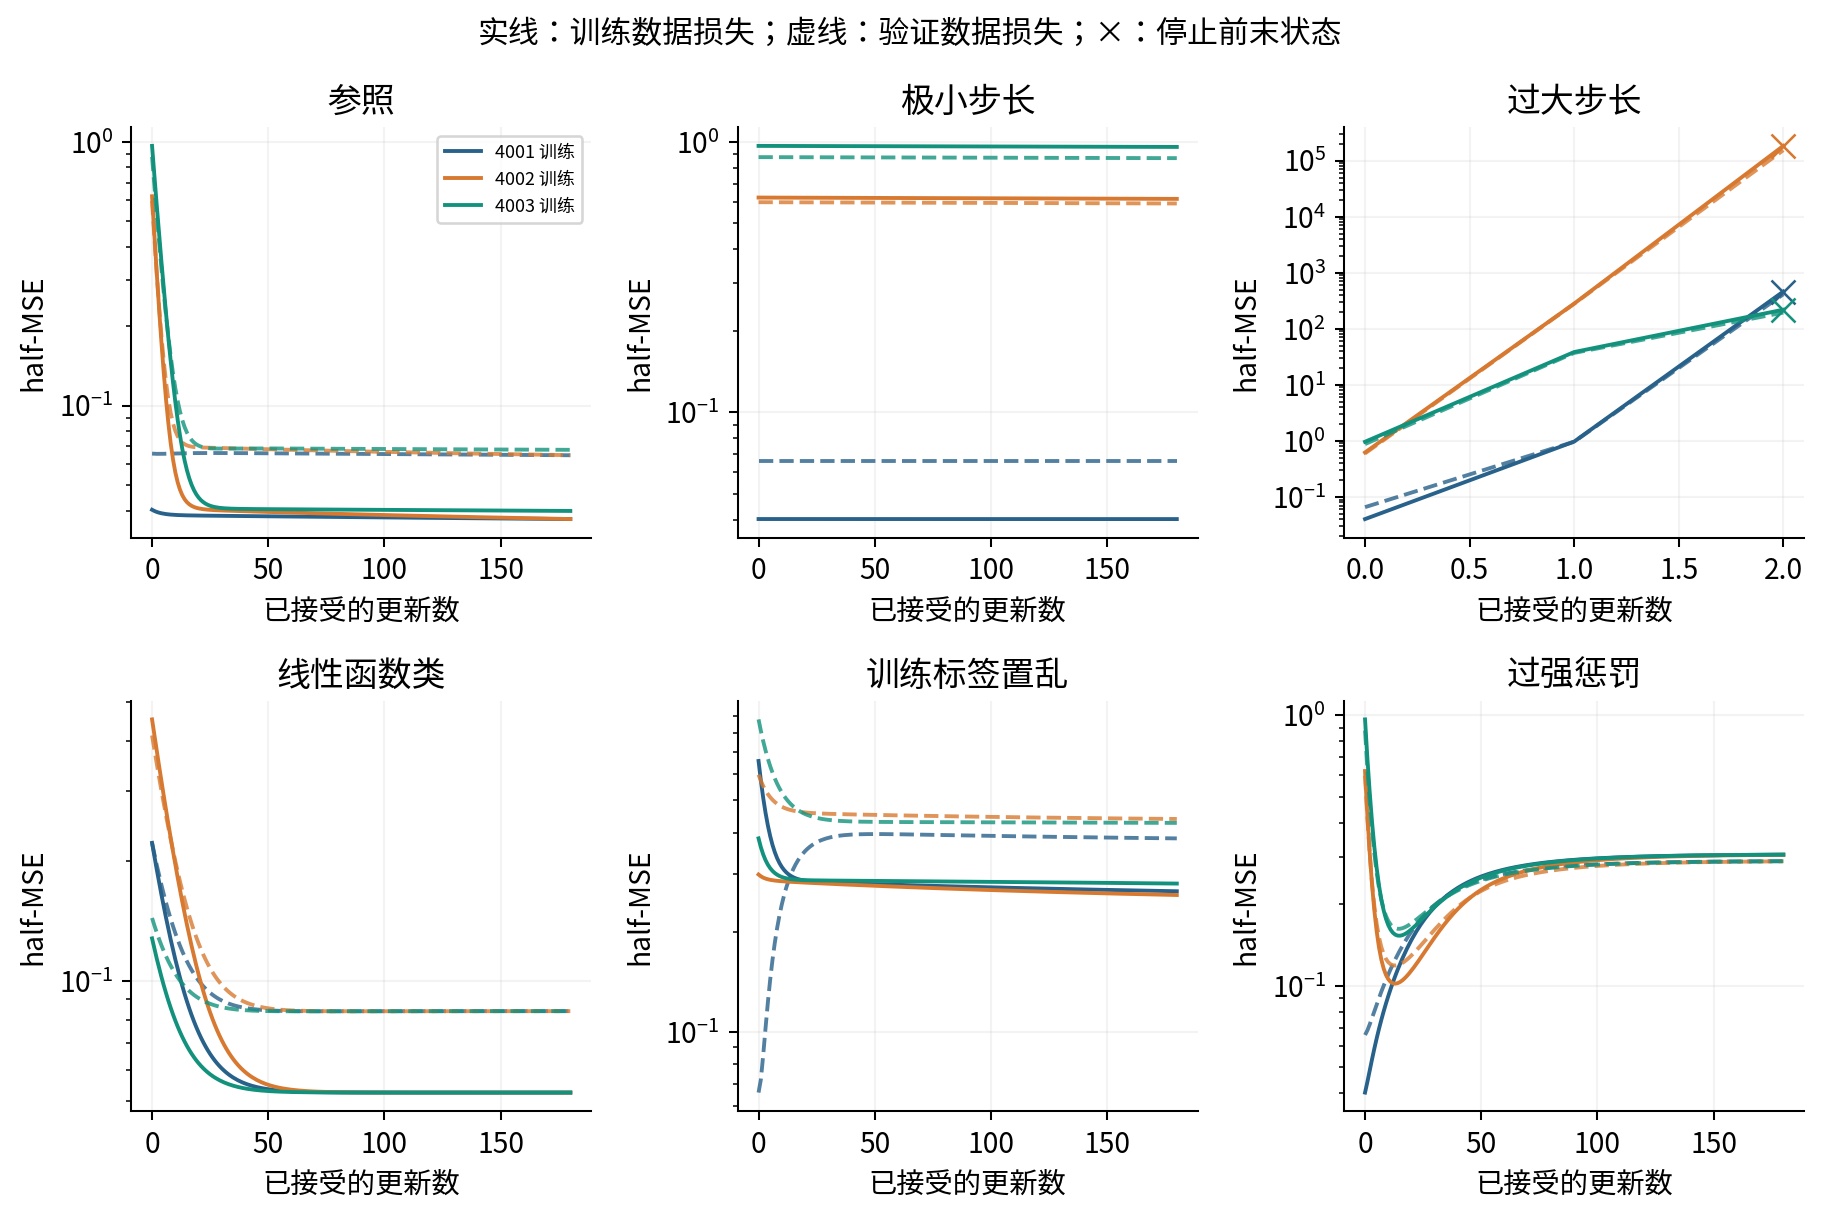

diagnostic-06 4001 2 3 1111463.9176463035
diagnostic-07 4002 2 3 153197253.38263544
diagnostic-08 4003 2 3 1260087.3049783593


In [7]:
display(Image(filename=str(BASE/'figures/04_diagnostic_curves.png')))
for r in runs:
    if r['failure']:
        print(r['run_id'],r['seed'],r['updates_applied'],r['failure']['attempted_update'],r['failure']['candidate_objective'])

## 7 保留与直觉相反的观测
饱和比例上升不自动说明任务失败。不要把诊断中更好的条件事后塞进主获胜者。

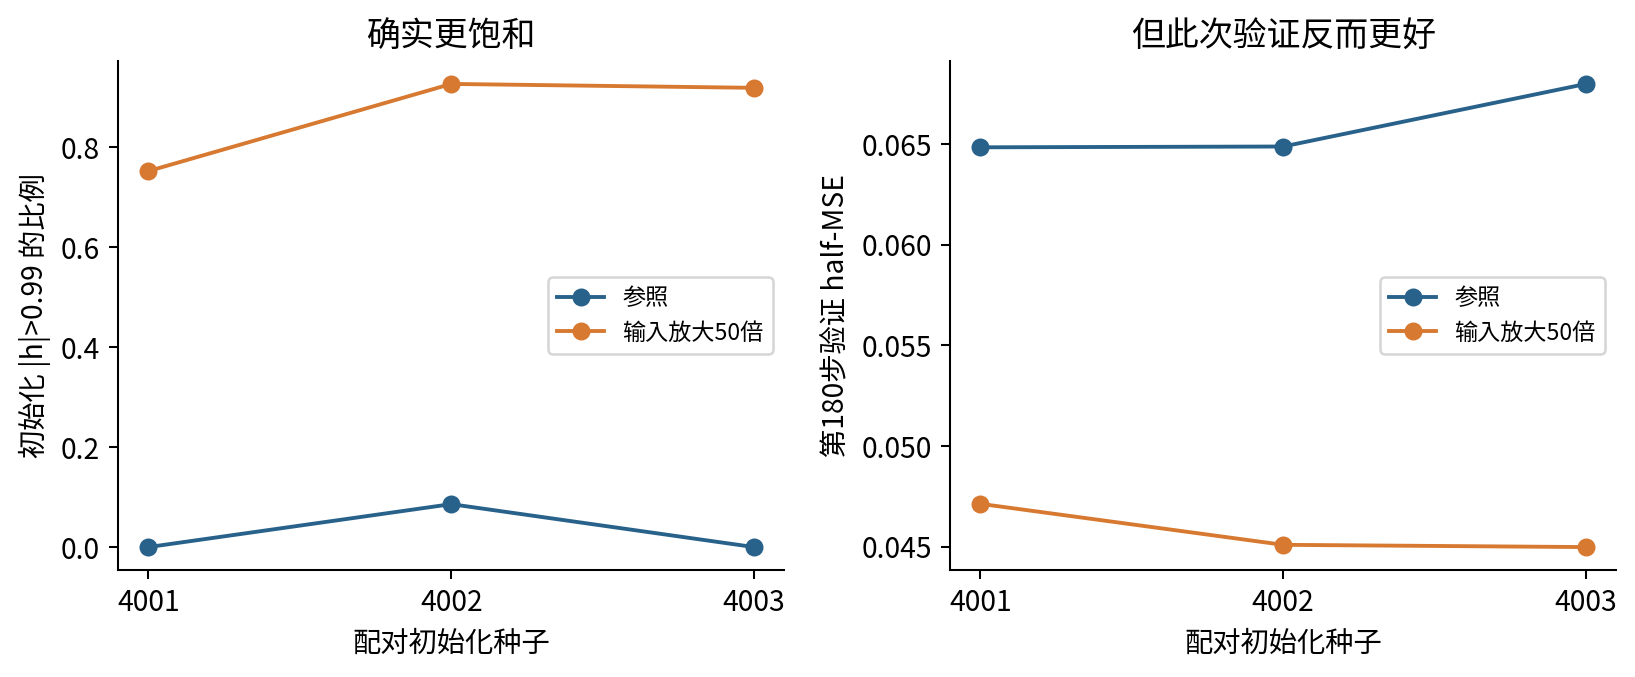

reference 4001 initial saturation: 0.0 final validation: 0.06483743871324935
reference 4002 initial saturation: 0.0859375 final validation: 0.06487724543112505
reference 4003 initial saturation: 0.0 final validation: 0.06798683990022585
saturated_input 4001 initial saturation: 0.7526041666666666 final validation: 0.0471246517846678
saturated_input 4002 initial saturation: 0.9270833333333334 final validation: 0.04508851583973161
saturated_input 4003 initial saturation: 0.9192708333333334 final validation: 0.044976312737888414
small probes: [('intact', 0.0026421887557938166), ('permuted', 0.08383443813901481)]
overfit probe: {'best_validation_step': 216, 'best_validation_loss': 0.05617050392719224, 'final_validation_loss': 0.06067942542328315, 'final_train_loss': 0.011308343949905316, 'used_for_main_selection': False}


In [8]:
display(Image(filename=str(BASE/'figures/05_saturation_counterexample.png')))
for r in runs:
    if r['stage']=='diagnostic' and r['config']['id'] in ('reference','saturated_input'):
        print(r['config']['id'],r['seed'],'initial saturation:',r['curve'][0]['saturated_fraction'],
              'final validation:',r['curve'][-1]['validation_data_loss'])
print('small probes:',[(r['config']['label_mode'],r['curve'][-1]['train_data_loss']) for r in runs if r['stage']=='tiny_probe'])
print('overfit probe:',result['overfit_probe'])

## 8 全部网格与12组单因素配对
选出的配置相对参照改了两项，整体差不只归于学习率。

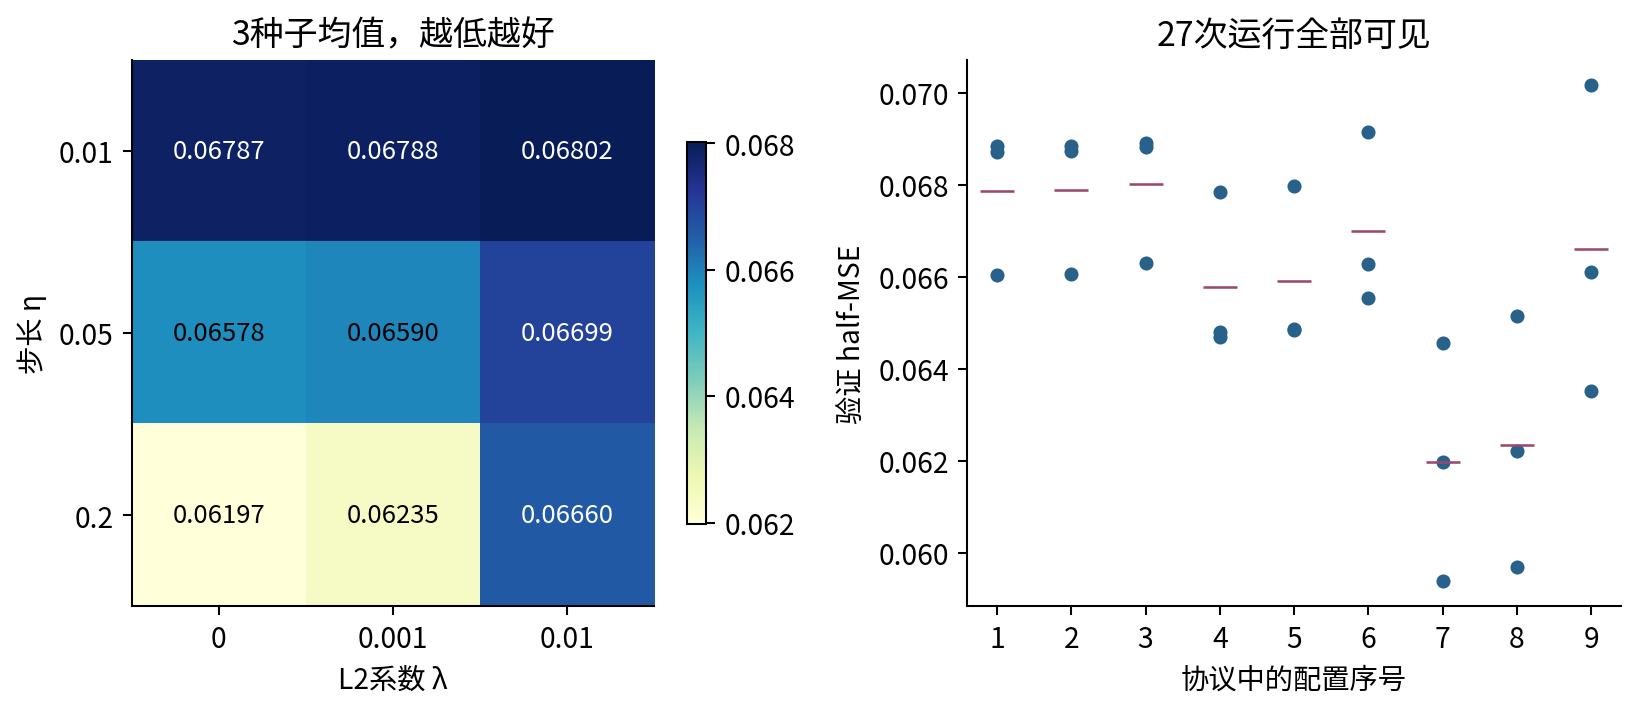

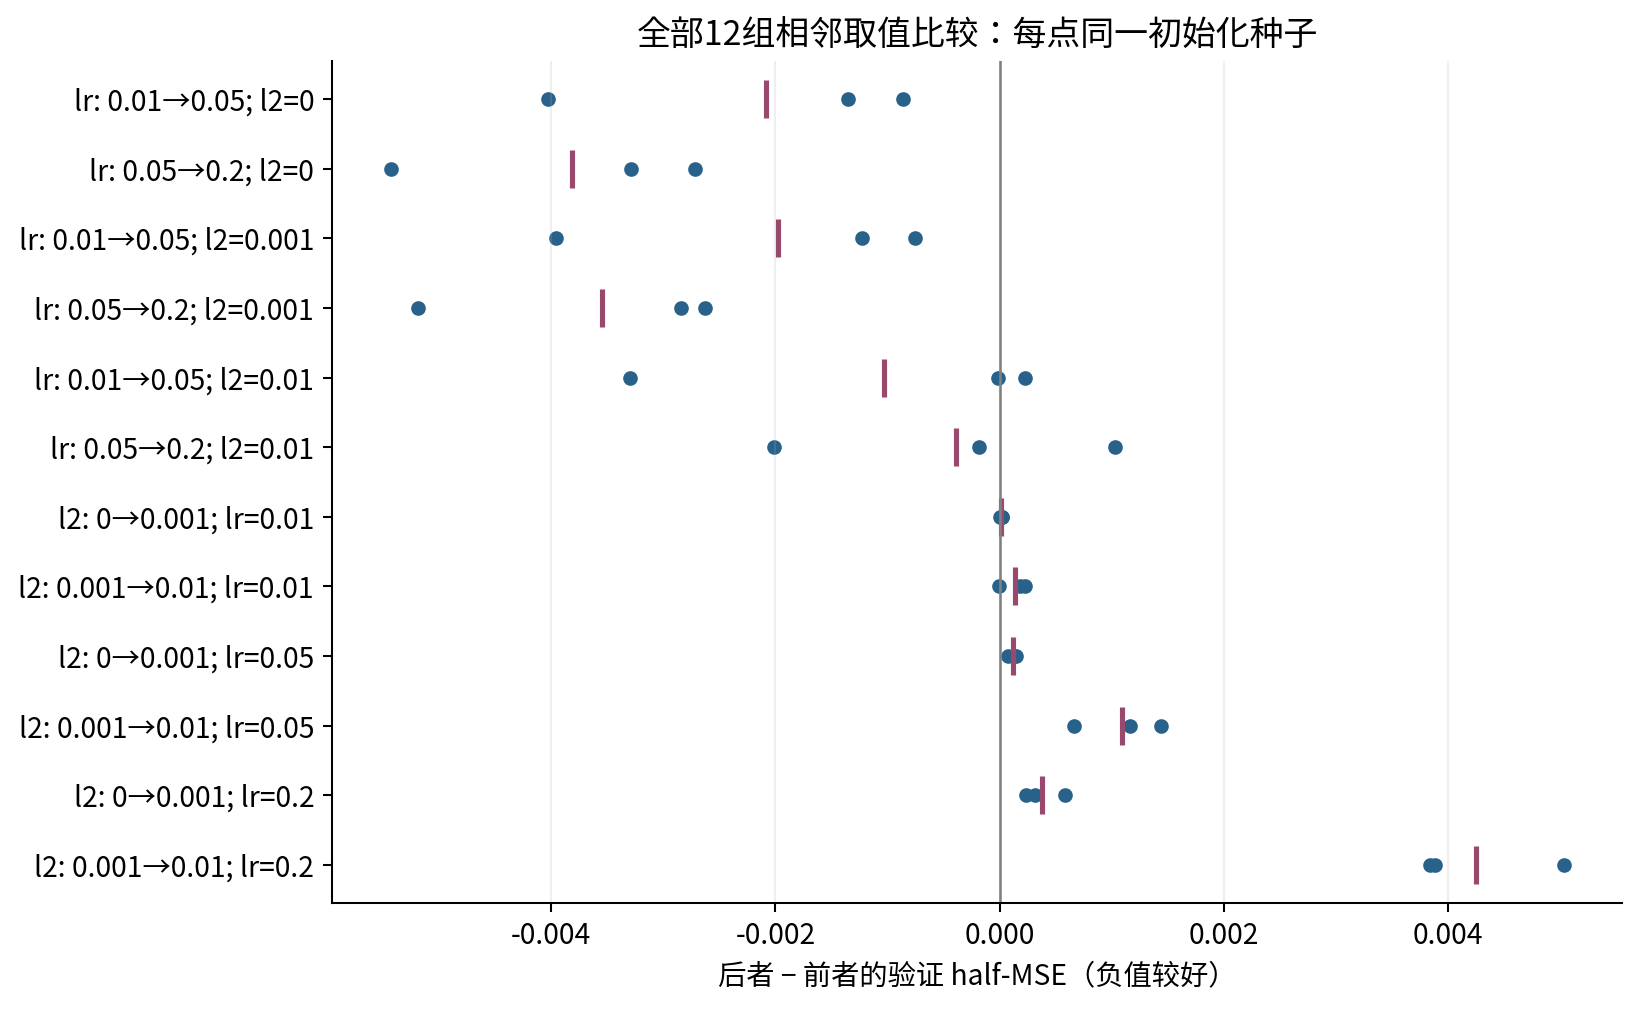

lr0-l20 0.06786746824490382
lr0-l21 0.06788176891364593
lr0-l22 0.0680185778291355
lr1-l20 0.06578411658688475
lr1-l21 0.06590050801486674
lr1-l22 0.06698858267181729
lr2-l20 0.061971577520655075
lr2-l21 0.062349097885017905
lr2-l22 0.06660067489910598
lr0-l20 to lr1-l20 [-0.0013549126805074002, -0.004032774850885712, -0.0008623674426640887]
lr1-l20 to lr2-l20 [-0.002714014934946246, -0.005432270959686729, -0.003291331304056039]
lr0-l21 to lr1-l21 [-0.0012301204560720147, -0.003961822013180447, -0.0007518402270851043]
lr1-l21 to lr2-l21 [-0.0026245091780527016, -0.005188931376523966, -0.0028407898349698674]
lr0-l22 to lr1-l22 [-1.73920019629209e-05, -0.0032942124229577013, 0.00022161895296604617]
lr1-l22 to lr2-l22 [-0.00018061528512447467, -0.0020153401705688134, 0.0010322321375593746]
lr0-l20 to lr0-l21 [2.4169179331179347e-05, -8.729777422195051e-07, 1.9605804637404245e-05]
lr0-l21 to lr0-l22 [0.00022793224601534712, -2.247242824784945e-06, 0.00018474174327806625]
lr1-l20 to lr1-l21

In [9]:
display(Image(filename=str(BASE/'figures/07_search_grid.png')))
display(Image(filename=str(BASE/'figures/08_paired_single_factor.png')))
for score in result['search_scores']:print(score['id'],score['mean_validation_half_mse'])
for contrast in result['single_factor_contrasts']:
    print(contrast['from_id'],'to',contrast['to_id'],contrast['paired_seed_differences'])
print('selected:',result['selected_id'],'baseline:',result['baseline_id'])

## 9 固定选择后的测试报告
平均单模型损失与平均预测的损失不是同一个量。本计划按前者选配置，按后者描述部署集成。

In [10]:
final=json.loads((BASE/'outputs/final_evaluation.json').read_text())
for metric in final['ensemble_metrics']:print(metric)
for label in ('baseline','selected'):
    seed_mean=np.mean([v['half_mse'] for v in final['seed_results'] if v['label']==label])
    ensemble=next(v['half_mse'] for v in final['ensemble_metrics'] if v['model']==label and v['group']=='all')
    print(label,'mean seed loss:',seed_mean,'ensemble loss:',ensemble)
print('test does not set a new winner')

{'model': 'baseline', 'group': 'all', 'n': 512, 'half_mse': 0.05093143950586965, 'rmse': 0.3191596450238333, 'mean_residual': -0.023968511804352256}
{'model': 'baseline', 'group': 'left', 'n': 269, 'half_mse': 0.025268773388822927, 'rmse': 0.22480557550391372, 'mean_residual': 0.003611900914355822}
{'model': 'baseline', 'group': 'right', 'n': 243, 'half_mse': 0.07933990528976086, 'rmse': 0.39834634500585253, 'mean_residual': -0.05449991518432127}
{'model': 'selected', 'group': 'all', 'n': 512, 'half_mse': 0.0484049018665904, 'rmse': 0.31114273851912533, 'mean_residual': -0.0056182403550527876}
{'model': 'selected', 'group': 'left', 'n': 269, 'half_mse': 0.024303914976723632, 'rmse': 0.22047183483031854, 'mean_residual': 0.0020919338233735944}
{'model': 'selected', 'group': 'right', 'n': 243, 'half_mse': 0.07508459517265689, 'rmse': 0.387516696860037, 'mean_residual': -0.014153371441458926}
{'model': 'constant', 'group': 'all', 'n': 512, 'half_mse': 0.3122670816164943, 'rmse': 0.7902747

## 10 配对bootstrap的条件范围
按独立测试ID重采样，同时保留两种预测；没有重训或重新选择。

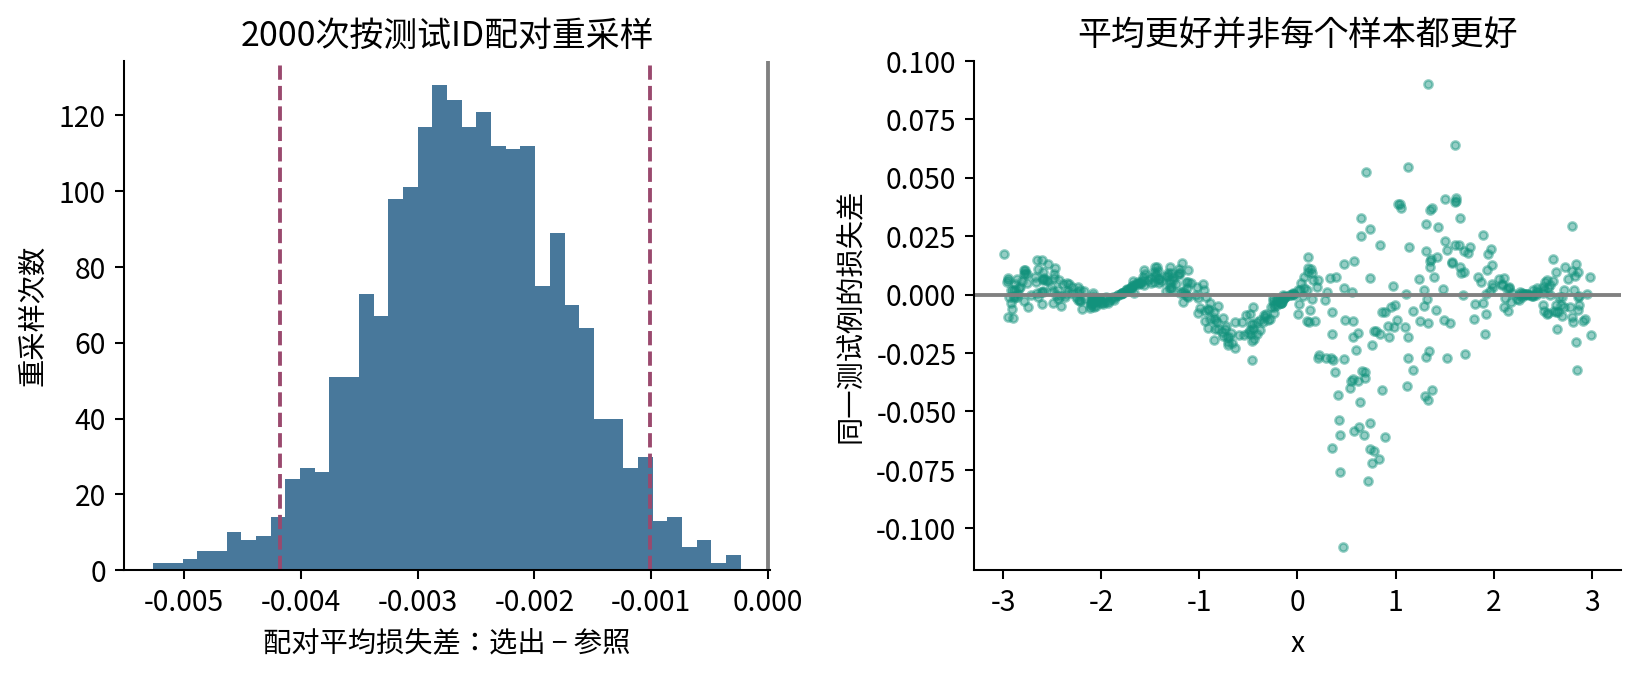

-0.0025265376392792456 [-0.004174868317020138, -0.0010084733667433021] fixed training/selection and fitted ensembles; independent test rows only


In [11]:
display(Image(filename=str(BASE/'figures/11_conditional_bootstrap.png')))
pb=final['paired_bootstrap'];differences=np.array(pb['row_differences'])
redo=e.paired_bootstrap(differences,2000,4091)
np.testing.assert_allclose(redo['bootstrap_means'],pb['bootstrap_means'],atol=0,rtol=0)
print(pb['mean'],pb['interval_percentile_95'],pb['conditional_scope'])

## 11 选择偏差的独立机制实验
分数噪声模拟不是神经网络训练；Bernoulli例的候选错误独立是特设假设。

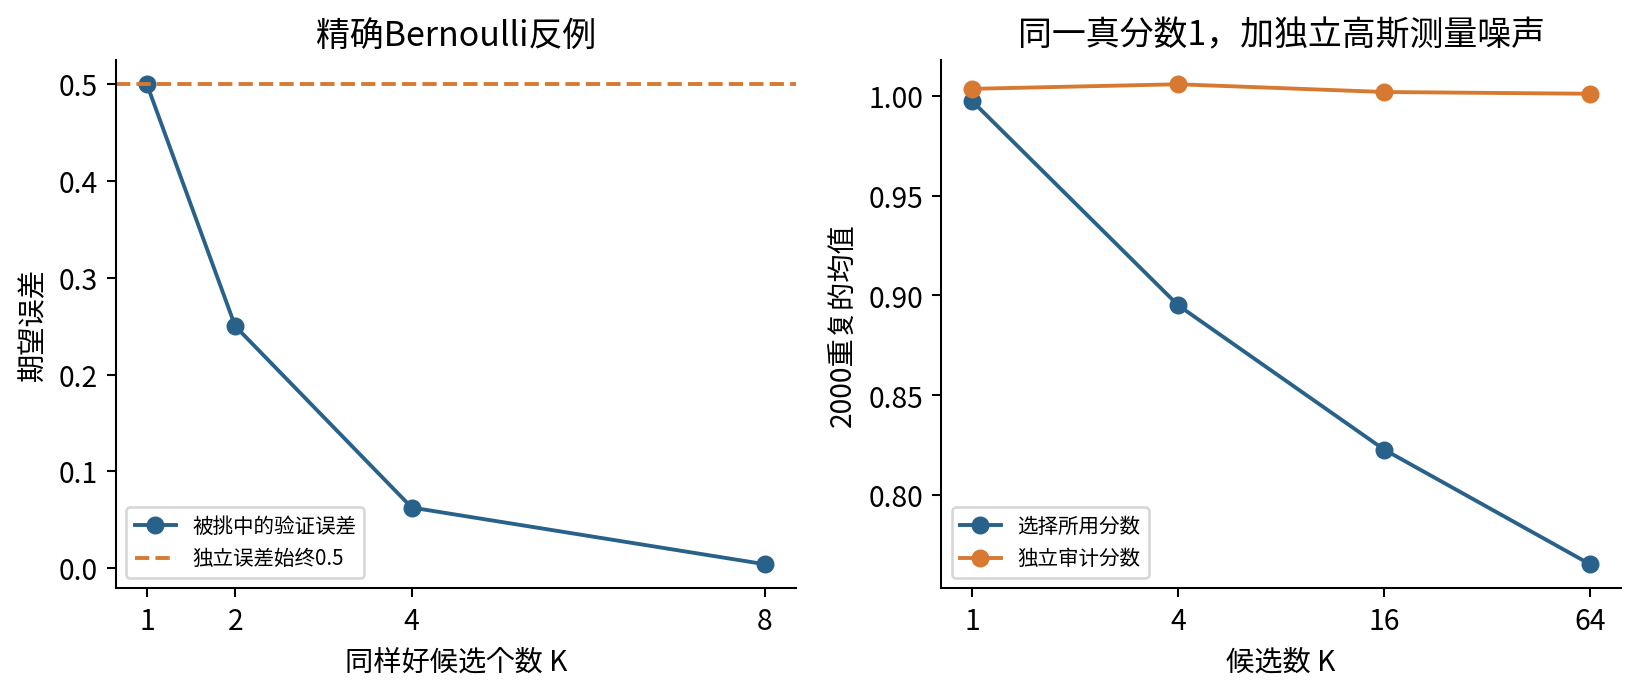

{'k': 1, 'expected_selected_validation_error': 0.5, 'independent_error': 0.5, 'optimism': 0.0}
{'k': 2, 'expected_selected_validation_error': 0.25, 'independent_error': 0.5, 'optimism': 0.25}
{'k': 4, 'expected_selected_validation_error': 0.0625, 'independent_error': 0.5, 'optimism': 0.4375}
{'k': 8, 'expected_selected_validation_error': 0.00390625, 'independent_error': 0.5, 'optimism': 0.49609375}
1 0.9972774464849116 1.0033729224187469 0.006095475933835102 0.003212514150576436
4 0.8950954918868773 1.0056602460123736 0.11056475412549627 0.0027157110628598102
16 0.8229182873426943 1.001792537711308 0.17887425036861335 0.002560836560058238
64 0.7655231366407718 1.000911653892746 0.23538851725197413 0.002419769793106412


In [12]:
display(Image(filename=str(BASE/'figures/12_selection_optimism.png')))
sim=e.selection_noise_simulation()
for row in sim['bernoulli_exact']:print(row)
for row in sim['records']:print(row['candidates'],row['mean_validation'],row['mean_audit'],row['optimism'],row['mcse_optimism'])

## 12 真正运行测试
不是只导入模块。外部无关工作目录与-O检查另由新进程执行。

In [13]:
import test_experiment
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
tests=unittest.TextTestRunner(verbosity=1).run(suite)
if not tests.wasSuccessful():raise RuntimeError('测试失败')
print('executed test groups:',tests.testsRun)

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 23 tests in 0.051s

OK


executed test groups: 23


## 13 写出能被批评的有限结论
请写一个有证据支持的改进、一个仍未解释的反例，以及新实验不应继续使用当前测试集的原因。

In [14]:
print('51 training runs; 12206 accepted updates; all failures retained.')
print('No GPU, real-world benchmark or across-platform bitwise guarantee.')
print('Conditional test-row bootstrap is not uncertainty over retraining and retuning.')

51 training runs; 12206 accepted updates; all failures retained.
No GPU, real-world benchmark or across-platform bitwise guarantee.
Conditional test-row bootstrap is not uncertainty over retraining and retuning.
